In [2]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [36]:
df = pd.read_excel("data/calif_plan20_ext.xlsx")
pd.set_option('display.max_columns', None)
df = df.drop(["Calif"], axis=1)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Examen1     264 non-null    float64
 1   Examen2     264 non-null    float64
 2   Examen3     264 non-null    float64
 3   Practica1   264 non-null    float64
 4   Practica2   264 non-null    float64
 5   Practica3   264 non-null    float64
 6   Practica4   264 non-null    float64
 7   Practicas   264 non-null    float64
 8   Proyecto    264 non-null    float64
 9   Acreditado  264 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 20.8 KB


In [40]:
# Convertir las columnas de 0 a 8 en float
for col in df.columns[0:9]:
    df[col] = df[col].astype(float)

# Predicción 1 examen

## Inicialización

In [86]:

df_p1 = df.drop(["Examen2", "Examen3", "Practicas", "Practica2", "Practica3", "Practica4"], axis=1)

In [87]:
df_p1.head()

,Examen1,Practica1,Proyecto,Acreditado
0,0.0,78.57,90.666667,1
1,60.0,78.57,90.666667,1
2,90.0,100.00,89.110000,1
3,0.0,21.43,47.223333,0
4,70.0,57.14,42.223333,1


## Entrenamiento

In [88]:
datos_Y1 = df_p1["Acreditado"]
datos_X1 =df_p1.drop( ['Acreditado'], axis=1)

In [89]:
from sklearn.model_selection import train_test_split
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(datos_X1, datos_Y1, test_size=0.2, random_state=0, stratify=datos_Y1)

In [95]:
# Bosque
from sklearn.ensemble import RandomForestClassifier
rfclas1 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=1, max_depth=10, min_samples_split=5)#número de árboles a usar, corregir desbalance de clases
#rfclas1 = RandomForestClassifier(n_estimators=200, class_weight={0:1, 1:2}, random_state=1, max_depth=10, min_samples_split=5)#número de árboles a usar, corregir desbalance de clases
rfclas1.fit(X_train1, Y_train1)
rfclas1.score(X_test1, Y_test1)

0.8679245283018868

In [96]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfclas1, X_train1, Y_train1, cv=5)
print(scores)
print("Promedio:", scores.mean())

[0.90697674 0.80952381 0.80952381 0.88095238 0.83333333]
Promedio: 0.848062015503876


## Evaluación

In [97]:
Y_pred = rfclas1.predict(X_test1)
confusion_matrix(Y_test1,Y_pred)
print('Puntaje: ',str(f1_score(Y_test1,Y_pred, average='macro')))
print(classification_report(Y_test1,Y_pred))

Puntaje:  0.8338557993730407
              precision    recall  f1-score   support

           0       0.85      0.97      0.91        36
           1       0.92      0.65      0.76        17

    accuracy                           0.87        53
   macro avg       0.89      0.81      0.83        53
weighted avg       0.87      0.87      0.86        53



In [98]:
#Cambiar rangos para mejorar predicción de alumnos que sí aprueban
y_prob = rfclas1.predict_proba(X_test1)[:, 1]

y_pred_04 = (y_prob >= 0.4).astype(int)
y_pred_035 = (y_prob >= 0.35).astype(int)

from sklearn.metrics import classification_report

print("Umbral 0.4")
print(classification_report(Y_test1, y_pred_04))

print("Umbral 0.35")
print(classification_report(Y_test1, y_pred_035))

Umbral 0.4
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        36
           1       0.65      0.65      0.65        17

    accuracy                           0.77        53
   macro avg       0.74      0.74      0.74        53
weighted avg       0.77      0.77      0.77        53

Umbral 0.35
              precision    recall  f1-score   support

           0       0.88      0.78      0.82        36
           1       0.62      0.76      0.68        17

    accuracy                           0.77        53
   macro avg       0.75      0.77      0.75        53
weighted avg       0.79      0.77      0.78        53



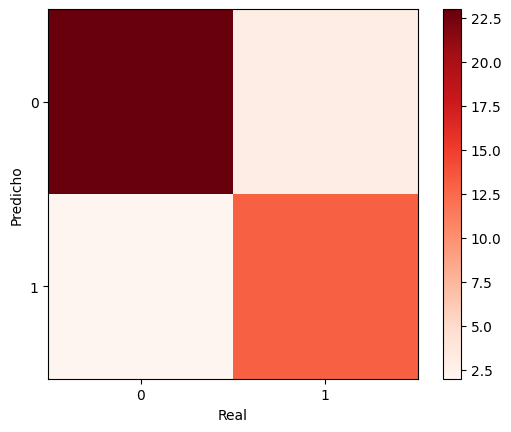

[[23  3]
 [ 2 13]]
Puntaje:  0.8780487804878049
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        26
           1       0.81      0.87      0.84        15

    accuracy                           0.88        41
   macro avg       0.87      0.88      0.87        41
weighted avg       0.88      0.88      0.88        41



In [ ]:
Y_pred = rfclas1.predict(X_test1)
# horizontales: predicho, verticales: reales
# hm = plt.imshow(confusion_matrix(Y_test1,Y_pred),cmap='Reds',interpolation="nearest")
# plt.colorbar(hm)
# plt.xlabel("Real")
# plt.ylabel("Predicho")
# cat_total = len(Y_train1.unique())
# plt.xticks(range(0, cat_total))
# plt.yticks(range(0, cat_total))
# plt.show()
print(hm.get_array())
print('Puntaje: ',str(f1_score(Y_test1,Y_pred, average='micro')))
print(classification_report(Y_test1,Y_pred))

## Guardar archivo

Entrenar con todos los datos

In [23]:
rfclas1.fit(datos_X1, datos_Y1)
rfclas1.score(X_test1, Y_test1)

0.9811320754716981

In [24]:
scores = cross_val_score(rfclas1, datos_X1, datos_Y1, cv=6)
print(scores)
print("Promedio:", scores.mean())

[0.77272727 0.84090909 0.88636364 0.81818182 0.88636364 0.75      ]
Promedio: 0.8257575757575758


In [25]:
from joblib import dump
dump(rfclas1, filename="data/prediccion_1cal.pkl")

['data/prediccion_1cal.pkl']

# Predicción 2 examen

## Inicialización

In [43]:
df_p2 = df.drop(["Examen3", "Practica3", "Practica4", "Practicas"], axis=1)

In [44]:
df_p2.head()

,Examen1,Examen2,Practica1,Practica2,Proyecto,Acreditado
0,0.0,65.0,78.57,95.0,90.666667,1
1,60.0,30.0,78.57,95.0,90.666667,1
2,90.0,80.0,100.00,100.0,89.110000,1
3,0.0,0.0,21.43,5.0,47.223333,0
4,70.0,85.0,57.14,60.0,42.223333,1


## Entrenamiento

In [45]:
datos_Y2 = df_p2["Acreditado"]
datos_X2 =df_p2.drop( ['Acreditado'], axis=1)

In [51]:
from sklearn.model_selection import train_test_split
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(datos_X2, datos_Y2, test_size=0.2, random_state=0, stratify=datos_Y2)

In [52]:
# Bosque
from sklearn.ensemble import RandomForestClassifier
rfclas2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=1, max_depth=10, min_samples_split=5)#número de árboles a usar
rfclas2.fit(X_train2, Y_train2)
rfclas2.score(X_test2, Y_test2)

0.8301886792452831

## Evaluación

In [53]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfclas2, X_train2, Y_train2, cv=5)
print(scores)
print("Promedio:", scores.mean())

[0.90697674 0.85714286 0.97619048 0.83333333 0.9047619 ]
Promedio: 0.8956810631229237


In [54]:
Y_pred = rfclas2.predict(X_test2)
confusion_matrix(Y_test2,Y_pred)
print('Puntaje: ',str(f1_score(Y_test2,Y_pred, average='macro')))
print(classification_report(Y_test2,Y_pred))

Puntaje:  0.8019925280199253
              precision    recall  f1-score   support

           0       0.86      0.89      0.88        36
           1       0.75      0.71      0.73        17

    accuracy                           0.83        53
   macro avg       0.81      0.80      0.80        53
weighted avg       0.83      0.83      0.83        53



In [55]:
#Cambiar rangos para mejorar predicción de alumnos que sí aprueban
y_prob = rfclas2.predict_proba(X_test2)[:, 1]

y_pred_04 = (y_prob >= 0.4).astype(int)
y_pred_035 = (y_prob >= 0.35).astype(int)

from sklearn.metrics import classification_report

print("Umbral 0.4")
print(classification_report(Y_test2, y_pred_04))

print("Umbral 0.35")
print(classification_report(Y_test2, y_pred_035))

Umbral 0.4
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        36
           1       0.75      0.88      0.81        17

    accuracy                           0.87        53
   macro avg       0.84      0.87      0.85        53
weighted avg       0.88      0.87      0.87        53

Umbral 0.35
              precision    recall  f1-score   support

           0       0.94      0.83      0.88        36
           1       0.71      0.88      0.79        17

    accuracy                           0.85        53
   macro avg       0.83      0.86      0.84        53
weighted avg       0.87      0.85      0.85        53



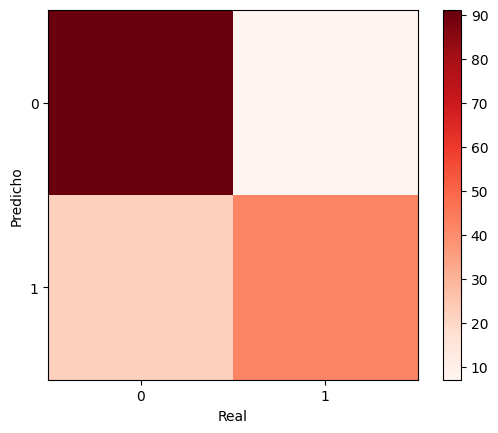

[[91  7]
 [22 42]]
Puntaje:  0.8209876543209876
              precision    recall  f1-score   support

           0       0.81      0.93      0.86        98
           1       0.86      0.66      0.74        64

    accuracy                           0.82       162
   macro avg       0.83      0.79      0.80       162
weighted avg       0.83      0.82      0.82       162



In [113]:
Y_pred = rfclas2.predict(X_test2)
# horizontales: predicho, verticales: reales
hm = plt.imshow(confusion_matrix(Y_test2,Y_pred),cmap='Reds',interpolation="nearest")
plt.colorbar(hm)
plt.xlabel("Real")
plt.ylabel("Predicho")
cat_total = len(Y_train2.unique())
plt.xticks(range(0, cat_total))
plt.yticks(range(0, cat_total))
plt.show()
print(hm.get_array())
print('Puntaje: ',str(f1_score(Y_test2,Y_pred, average='micro')))
print(classification_report(Y_test2,Y_pred))

In [84]:
importances = rfclas2.feature_importances_

feature_df_rf = pd.DataFrame({
    'Feature': X_train2.columns,
    'Importance': importances*100
}).sort_values(by='Importance', ascending=False)
print(feature_df_rf)

     Feature  Importance
1    Examen2   31.813490
0    Examen1   27.482512
4   Proyecto   26.983101
3  Practica2    8.258886
2  Practica1    5.462011


## Guardar

In [56]:
rfclas2.fit(datos_X2, datos_Y2)
rfclas2.score(X_test2, Y_test2)

0.9811320754716981

In [57]:
scores = cross_val_score(rfclas2, datos_X2, datos_Y2, cv=6)
print(scores)
print("Promedio:", scores.mean())

[0.86363636 0.81818182 0.90909091 0.95454545 0.90909091 0.84090909]
Promedio: 0.8825757575757575


In [58]:
dump(rfclas2, filename="data/prediccion_2cal.pkl")

['data/prediccion_2cal.pkl']

## Predicción

In [118]:
#@title Captura de calificaciones

examen = 0 #@param {type:"number", min:0, max:100}
examen2 = 10 #@param {type:"number", min:0, max:100}
practicas = 95 #@param {type:"number", min:0, max:100}
proyecto = 85 #@param {type:"number", min:0, max:100}

prediccion = pd.DataFrame({'Examen1':[examen], 'Examen2':[examen2], 'Practicas':[practicas], 'Proyecto':[proyecto]})
res = rfclas2.predict(prediccion)
if res[0] == 0:
  print("✖ No aprobará")
else:
  print("✔ Aprobará")

✖ No aprobará


# Porcentajes

In [ ]:
#@title Rubrica de calificaciones

r_examen = 10 #@param {type:"number", min:0, max:100}
r_examen2 = 50 #@param {type:"number", min:0, max:100}
r_examen3 = 50 #@param {type:"number", min:0, max:100}
r_practicas = 95 #@param {type:"number", min:0, max:100}
r_proyecto = 85 #@param {type:"number", min:0, max:100}
res = r_examen*.15+r_examen2*.2+r_examen3*.2+r_practicas*.2+r_proyecto*.25
print(f'Calificación final {res}')

Calificación final 61.75


# Correlación general

In [61]:
df_p3 = df.drop(["Practicas"], axis=1)

In [62]:
datos_Y3 = df_p3["Acreditado"]
datos_X3 =df_p3.drop( ['Acreditado'], axis=1)
from sklearn.model_selection import train_test_split
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(datos_X3, datos_Y3, random_state=0)

In [63]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
features_total = min(datos_X3.columns.size, 10) # Características/columnas deseadas
test = SelectKBest(score_func=chi2, k=features_total)
fit = test.fit(X_train3, Y_train3)
# Imprimir los mejores features ordenados
keys = list(datos_X3.columns)
values = list(fit.scores_)
res = {keys[i]: values[i] for i in range(len(keys))}# Convierte en diccionario
sorted_res = {key:value for key, value in sorted(res.items(), key=lambda
item:item[1], reverse=True)}
print(sorted_res)# Muestra ordenados

{'Examen3': np.float64(2567.9371767118605), 'Examen2': np.float64(2472.28947765951), 'Examen1': np.float64(2415.177303010663), 'Proyecto': np.float64(894.2028811986152), 'Practica3': np.float64(365.2544268074764), 'Practica4': np.float64(223.20913375427259), 'Practica2': np.float64(157.3106987614541), 'Practica1': np.float64(53.455876471479755)}


In [80]:
percentages = values / sum(values) * 100
feature_df = pd.DataFrame.from_dict(
    dict(zip(keys, percentages)),
    orient='index',
    columns=['Percentage']
)
feature_df = feature_df.sort_values(
    by="Percentage",
    ascending=False
)
feature_df["Percentage"] = feature_df["Percentage"].round(2)
feature_df.head(10)

,Percentage
Examen3,28.07
Examen2,27.02
Examen1,26.40
Proyecto,9.77
Practica3,3.99
Practica4,2.44
Practica2,1.72
Practica1,0.58


In [81]:
feature_df.to_pickle("data/feature_importance_chi2.pkl")

In [21]:
df_p3.corr().style.background_gradient(cmap='RdYlGn')

,Examen1,Examen2,Examen3,Practica1,Practica2,Practica3,Practica4,Proyecto,Acreditado
Examen1,1.000000,0.590224,0.555044,0.210705,0.175476,0.196863,0.284118,0.328104,0.597667
Examen2,0.590224,1.000000,0.593642,0.092981,0.161060,0.145466,0.256257,0.256705,0.601194
Examen3,0.555044,0.593642,1.000000,0.091689,0.168172,0.188701,0.248684,0.270353,0.573983
Practica1,0.210705,0.092981,0.091689,1.000000,0.489366,0.396394,0.289583,0.432090,0.264749
Practica2,0.175476,0.161060,0.168172,0.489366,1.000000,0.477226,0.301970,0.388227,0.320184
Practica3,0.196863,0.145466,0.188701,0.396394,0.477226,1.000000,0.439543,0.471202,0.306061
Practica4,0.284118,0.256257,0.248684,0.289583,0.301970,0.439543,1.000000,0.385191,0.347150
Proyecto,0.328104,0.256705,0.270353,0.432090,0.388227,0.471202,0.385191,1.000000,0.518929
Acreditado,0.597667,0.601194,0.573983,0.264749,0.320184,0.306061,0.347150,0.518929,1.000000
